**Install dependencies**

In [ ]:
!pip install pystac stac-asset rasterio nest_asyncio

**Imports & setup**

In [ ]:
!pip install pystac rasterio scikit-image

import numpy as np
import matplotlib.pyplot as plt
import rasterio
import pystac

from scipy.ndimage import (
    uniform_filter,
    binary_opening,
    binary_closing,
    binary_dilation,
    distance_transform_edt
)

from skimage.measure import label, regionprops

**Load STAC collection**

In [ ]:
collection = pystac.Collection.from_file(
    "https://capella-open-data.s3.us-west-2.amazonaws.com/stac/capella-open-data-ieee-data-contest/collection.json"
)

items = [pystac.Item.from_file(l.absolute_href) for l in collection.get_item_links()]
print("Total items:", len(items))

Total items: 1582


In [ ]:
BBOX = [1.5, 41.0, 2.8, 41.8]  # Barcelona area

**Filter by BBOX + polarization**

In [ ]:
def intersects_bbox(item, bbox):
    if item.bbox is None:
        return False
    ib = item.bbox
    return not (
        ib[2] < bbox[0] or ib[0] > bbox[2] or
        ib[3] < bbox[1] or ib[1] > bbox[3]
    )

items = [i for i in items if intersects_bbox(i, BBOX)]
print("After BBOX filter:", len(items))

After BBOX filter: 20


**Keep GEO only + sort by time**

In [ ]:
items = [
    i for i in items
    if i.properties.get("sar:product_type") == "GEO"
    and "HH" in (i.properties.get("sar:polarizations") or [])
]

print("GEO + HH items:", len(items))

GEO + HH items: 10


**Extract ONE image URL**

In [ ]:
def get_asset_href(item):
    for key, asset in item.assets.items():
        if "tif" in asset.href.lower():
            return asset.href
    return None

urls = [get_asset_href(i) for i in items]
urls = [u for u in urls if u is not None]

print("Valid images:", len(urls))

# pick first image
url = urls[0]
print("Using:", url)

Valid images: 10
Using: https://capella-open-data.s3.amazonaws.com/data/2022/6/1/CAPELLA_C08_SP_GEO_HH_20220601214346_20220601214403/CAPELLA_C08_SP_GEO_HH_20220601214346_20220601214403.tif


**Open image**

In [ ]:
import rasterio

ds = rasterio.open(url)

print(ds)

<open DatasetReader name='https://capella-open-data.s3.amazonaws.com/data/2022/6/1/CAPELLA_C08_SP_GEO_HH_20220601214346_20220601214403/CAPELLA_C08_SP_GEO_HH_20220601214346_20220601214403.tif' mode='r'>


**Read SMALL version**

In [ ]:
from rasterio.enums import Resampling
import numpy as np

arr = ds.read(
    1,
    out_shape=(ds.height // 6, ds.width // 6),
    resampling=Resampling.nearest
).astype(float)

print("Shape:", arr.shape)

Shape: (2395, 2391)


**Quick visualize**

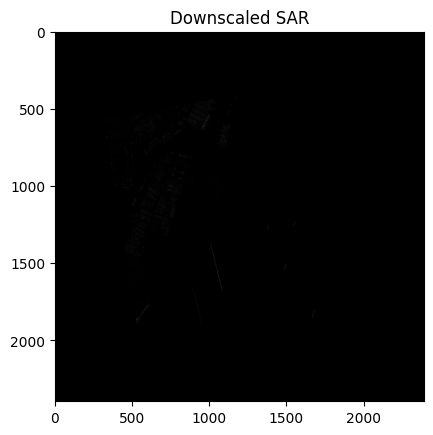

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(arr, cmap='gray')
plt.title("Downscaled SAR")
plt.show()

In [ ]:
from scipy.ndimage import (
    uniform_filter,
    binary_opening,
    binary_closing,
    binary_dilation,
    distance_transform_edt
)

In [ ]:
sigma0 = arr.copy()

valid_mask = sigma0 > 0
sigma0[~valid_mask] = np.nan

**Lee Filter**

In [ ]:
def lee_filter_nan(img, size=7):
    img_filled = np.nan_to_num(img, nan=0.0)

    mean = uniform_filter(img_filled, size)
    mean_sq = uniform_filter(img_filled**2, size)
    var = mean_sq - mean**2

    overall_var = np.nanvar(img_filled)

    w = var / (var + overall_var + 1e-6)

    return mean + w * (img_filled - mean)

sigma0_f = lee_filter_nan(sigma0, size=7)
sigma0_f[~valid_mask] = np.nan

**Water mask**

In [ ]:
water_mask = valid_mask.copy()

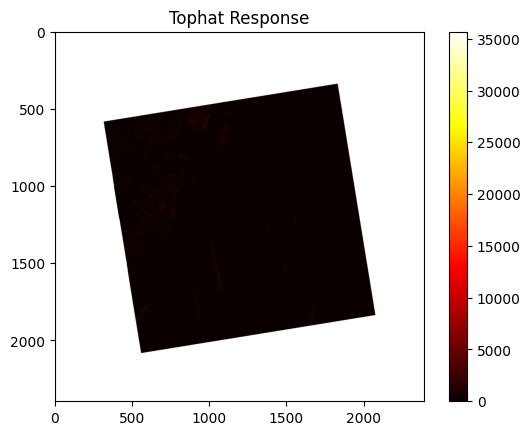

In [ ]:
# IMPORTANT: DO NOT LOG TRANSFORM
img = sigma0_f.copy()

# Larger kernel (ships are not tiny)
selem = disk(15)

tophat = white_tophat(img, selem)

plt.imshow(tophat, cmap='hot')
plt.title("Tophat Response")
plt.colorbar()
plt.show()

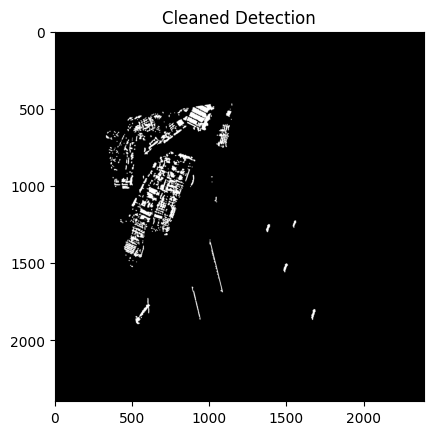

In [ ]:
ship_mask = binary_opening(ship_mask, structure=np.ones((3,3)))
ship_mask = binary_dilation(ship_mask, structure=np.ones((3,3)))

plt.imshow(ship_mask, cmap='gray')
plt.title("Cleaned Detection")
plt.show()

In [ ]:
labeled = label(ship_mask)
regions = regionprops(labeled)

ships = [r for r in regions if 3 < r.area < 500]

print("Object detected:", len(ships))

Ships detected: 328


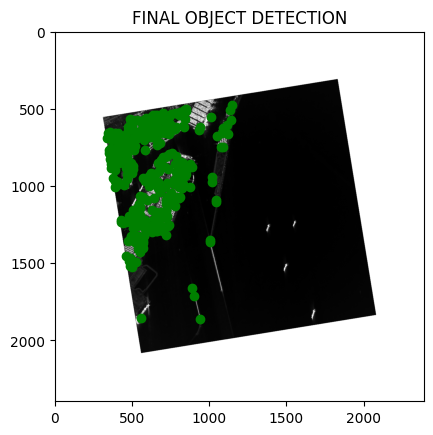

In [ ]:
plt.imshow(
    sigma0_f,
    cmap='gray',
    vmin=np.nanpercentile(sigma0_f, 5),
    vmax=np.nanpercentile(sigma0_f, 99)
)

for r in ships:
    y, x = r.centroid
    plt.plot(x, y, 'go')

plt.title("FINAL OBJECT DETECTION")
plt.show()

In [ ]:
def detect_objects(url):
    import rasterio
    import numpy as np
    from rasterio.enums import Resampling
    from scipy.ndimage import uniform_filter, binary_opening, binary_dilation
    from skimage.measure import label, regionprops
    from skimage.morphology import white_tophat, disk

    # Load image
    ds = rasterio.open(url)

    arr = ds.read(
        1,
        out_shape=(ds.height // 6, ds.width // 6),
        resampling=Resampling.nearest
    ).astype(float)

    # Prepare
    sigma0 = arr.copy()
    valid_mask = sigma0 > 0
    sigma0[~valid_mask] = np.nan

    # Lee filter
    def lee_filter_nan(img, size=7):
        img_filled = np.nan_to_num(img, nan=0.0)
        mean = uniform_filter(img_filled, size)
        mean_sq = uniform_filter(img_filled**2, size)
        var = mean_sq - mean**2
        overall_var = np.nanvar(img_filled)
        w = var / (var + overall_var + 1e-6)
        return mean + w * (img_filled - mean)

    sigma0_f = lee_filter_nan(sigma0, size=7)
    sigma0_f[~valid_mask] = np.nan

    # Top-hat detection
    selem = disk(15)
    tophat = white_tophat(sigma0_f, selem)

    # LOWER threshold → detect ALL objects
    threshold = np.nanpercentile(tophat, 90)

    object_mask = (tophat > threshold)

    # Clean
    object_mask = binary_opening(object_mask, structure=np.ones((3,3)))
    object_mask = binary_dilation(object_mask, structure=np.ones((3,3)))

    # Label
    labeled = label(object_mask)
    regions = regionprops(labeled)

    # Relaxed filtering (detect ALL objects)
    objects = [r for r in regions if r.area > 3]

    return len(objects), objects

In [ ]:
results = []

for i, url in enumerate(urls):
    print(f"\nProcessing image {i}...")

    try:
        count, objs = detect_objects(url)
        results.append(count)
        print(f"→ Objects detected: {count}")

    except Exception as e:
        print(f"Error on image {i}: {e}")
        results.append(None)


Processing image 0...
→ Objects detected: 185

Processing image 1...
→ Objects detected: 152

Processing image 2...
→ Objects detected: 155

Processing image 3...
→ Objects detected: 156

Processing image 4...
→ Objects detected: 522

Processing image 5...
→ Objects detected: 420

Processing image 6...
→ Objects detected: 470

Processing image 7...
→ Objects detected: 532

Processing image 8...
→ Objects detected: 1775

Processing image 9...
→ Objects detected: 2950


In [ ]:
print("\n=== OBJECT COUNT PER IMAGE ===")
for i, n in enumerate(results):
    print(f"Image {i}: {n} objects")


=== OBJECT COUNT PER IMAGE ===
Image 0: 185 objects
Image 1: 152 objects
Image 2: 155 objects
Image 3: 156 objects
Image 4: 522 objects
Image 5: 420 objects
Image 6: 470 objects
Image 7: 532 objects
Image 8: 1775 objects
Image 9: 2950 objects


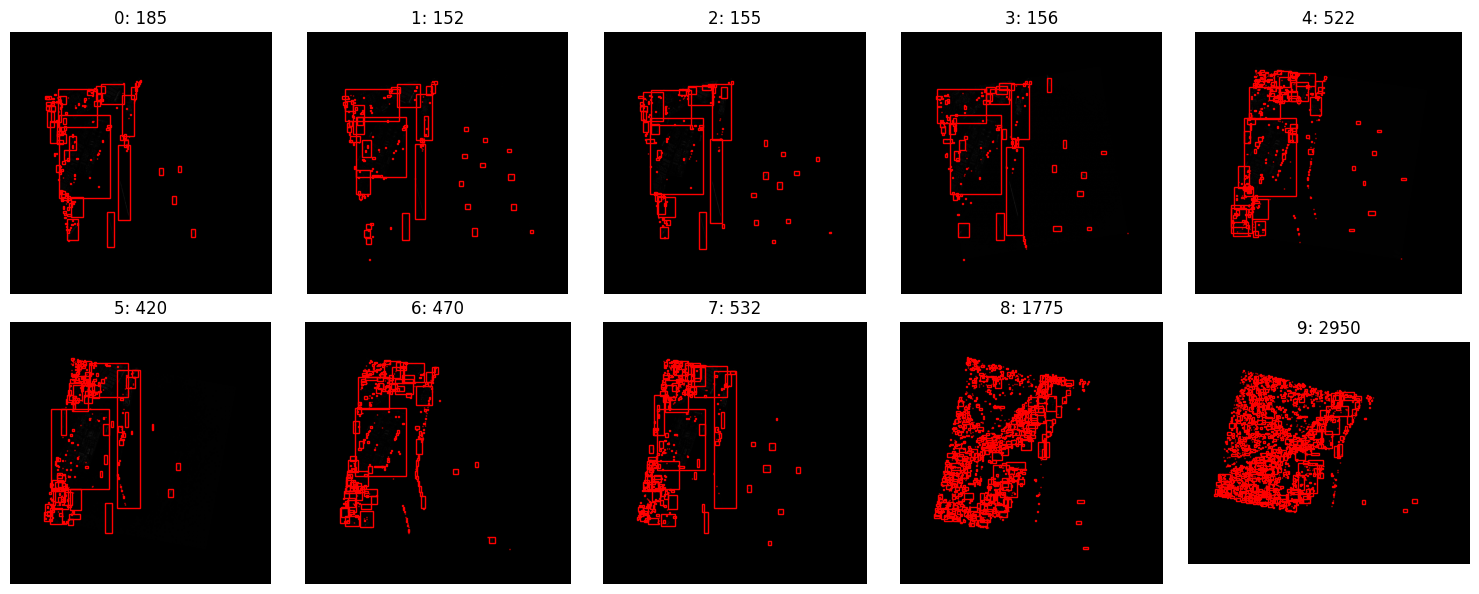

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 5, figsize=(15,6))  # 10 images

for i, (url, ax) in enumerate(zip(urls, axes.flatten())):
    try:
        count, objects = detect_objects(url)

        ds = rasterio.open(url)
        arr = ds.read(
            1,
            out_shape=(ds.height // 6, ds.width // 6),
            resampling=Resampling.nearest
        )

        ax.imshow(arr, cmap='gray')

        for r in objects:
            minr, minc, maxr, maxc = r.bbox
            ax.add_patch(
                plt.Rectangle(
                    (minc, minr),
                    maxc - minc,
                    maxr - minr,
                    edgecolor='red',
                    fill=False,
                    linewidth=1
                )
            )

        ax.set_title(f"{i}: {count}")
        ax.axis('off')

    except Exception as e:
        ax.set_title(f"{i}: ERROR")
        ax.axis('off')

plt.tight_layout()
plt.show()